#**Project 2: Diabetes Binary Classification Analysis**

**Name:** Jo Yuan  
**Course:** INTD 555  
**Instructor:** Dr. Tasnim  
**Date:** April 2026

In this notebook, I analyze the **Pima Indians Diabetes Dataset**, which contains **8 clinical health attributes** used to predict whether a patient has diabetes.

---

**Dataset Source:**

The Pima Indians Diabetes Dataset was originally collected by the **National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)**. It contains diagnostic information for **768 female patients of Pima Indian heritage living near Phoenix, Arizona, USA**, and is widely used to study the onset of Type 2 Diabetes.

The dataset includes **8 clinical features** and one binary target variable. Among the observations, **258 cases are positive and 500 are negative**, forming a moderately imbalanced classification problem.

This dataset captures both genetic and environmental factors associated with diabetes risk and is commonly used in machine learning for healthcare prediction.

The dataset is publicly available through the UCI Machine Learning Repository:  
https://archive.ics.uci.edu/ml/datasets/diabetes  

Additional description adapted from:  
https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset/blob/master/README.md  

---

**Feature Variables:**

- `Pregnancies`: Number of times pregnant  
- `Glucose`: Plasma glucose concentration (2 hours in an oral glucose tolerance test)  
- `BloodPressure`: Diastolic blood pressure (mm Hg)  
- `SkinThickness`: Tricep skin fold thickness (mm)  
- `Insulin`: 2-hour serum insulin (mu U/ml)  
- `BMI`: Body mass index (weight in kg/(height in m)^2)  
- `DiabetesPedigreeFunction`: Likelihood of diabetes based on family history  
- `Age`: Age in years  

---

**Target Variable:**

- `Outcome`: Class variable (**0 = No Diabetes, 1 = Diabetes**)  

---

**Objective:**

The objective of this project is to build a **binary classification model** to predict diabetes status based on the given features.  
We follow a structured machine learning pipeline, including **data cleaning, exploratory data analysis (EDA), model training, evaluation, and optimization**.

**This analysis helps demonstrate how machine learning can be applied to real-world healthcare prediction problems.**


In [2]:
# 1. Fundamental Data Handling
import pandas as pd
import numpy as np

# 2. Visualizations (Crucial for Step 2 of your project)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Model Pipeline & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler

# 4. Classification Models (Comparing different algorithms as per Module 7)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# 5. Evaluation Metrics (The core of your project report)
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

print("All libraries imported successfully. Your environment is ready!")

All libraries imported successfully. Your environment is ready!



# Step 1: Read the data

First, we load the **Pima Indians Diabetes Dataset** into a pandas DataFrame from 'diabetes.csv'..

In [11]:
# 1. Load Dataset
df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Note: Handling Physiological Zeros in Medical Data

In this dataset, certain features such as *Glucose*, *BloodPressure*, *SkinThickness*, *Insulin*, and *BMI* contain zero values that are not physiologically plausible.  
**According to the dataset documentation, these values likely represent missing or unrecorded measurements rather than true observations.**

To address this issue, zero values in these columns are treated as missing values (`NaN`). Median imputation is then applied, as it is more robust to outliers and skewed distributions commonly observed in medical data.

This preprocessing step improves data quality and helps ensure more reliable and unbiased model performance.

In [13]:
# 2. Advanced Cleaning: Handling Physiological Zeros
# Medical logic: Glucose, Blood Pressure, BMI, etc., cannot be 0.
# We treat 0s as missing values (NaN) and impute them with the median.
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    df[col] = df[col].replace(0, np.nan)

# Impute using Median (More robust than mean for skewed medical data)
df.fillna(df.median(), inplace=True)

print("Data Cleaning Complete: Invalid zeros handled using median imputation.")
df.head()

Data Cleaning Complete: Invalid zeros handled using median imputation.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [15]:
print("Remaining zero values:")
print((df == 0).sum())

Remaining zero values:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


## **Step 2: Exploratory Data Analysis (EDA)**

In this section, I conduct exploratory data analysis to better understand the distribution and relationships within the dataset. I use histograms, bar charts, and box plots to visualize the data.



### Univariate Analysis


Rationale: I selected histograms to visualize the distribution of each clinical health attribute and identify potential data quality issues such as outliers or abnormal values.

Interpretation: The plots show that variables like Glucose and BMI follow a roughly normal distribution. More importantly, several variables contain biologically implausible zero values (e.g., BloodPressure, Insulin), which are not realistic in a clinical context. This observation informed the decision to treat these zeros as missing values and apply median imputation to improve data quality before modeling.

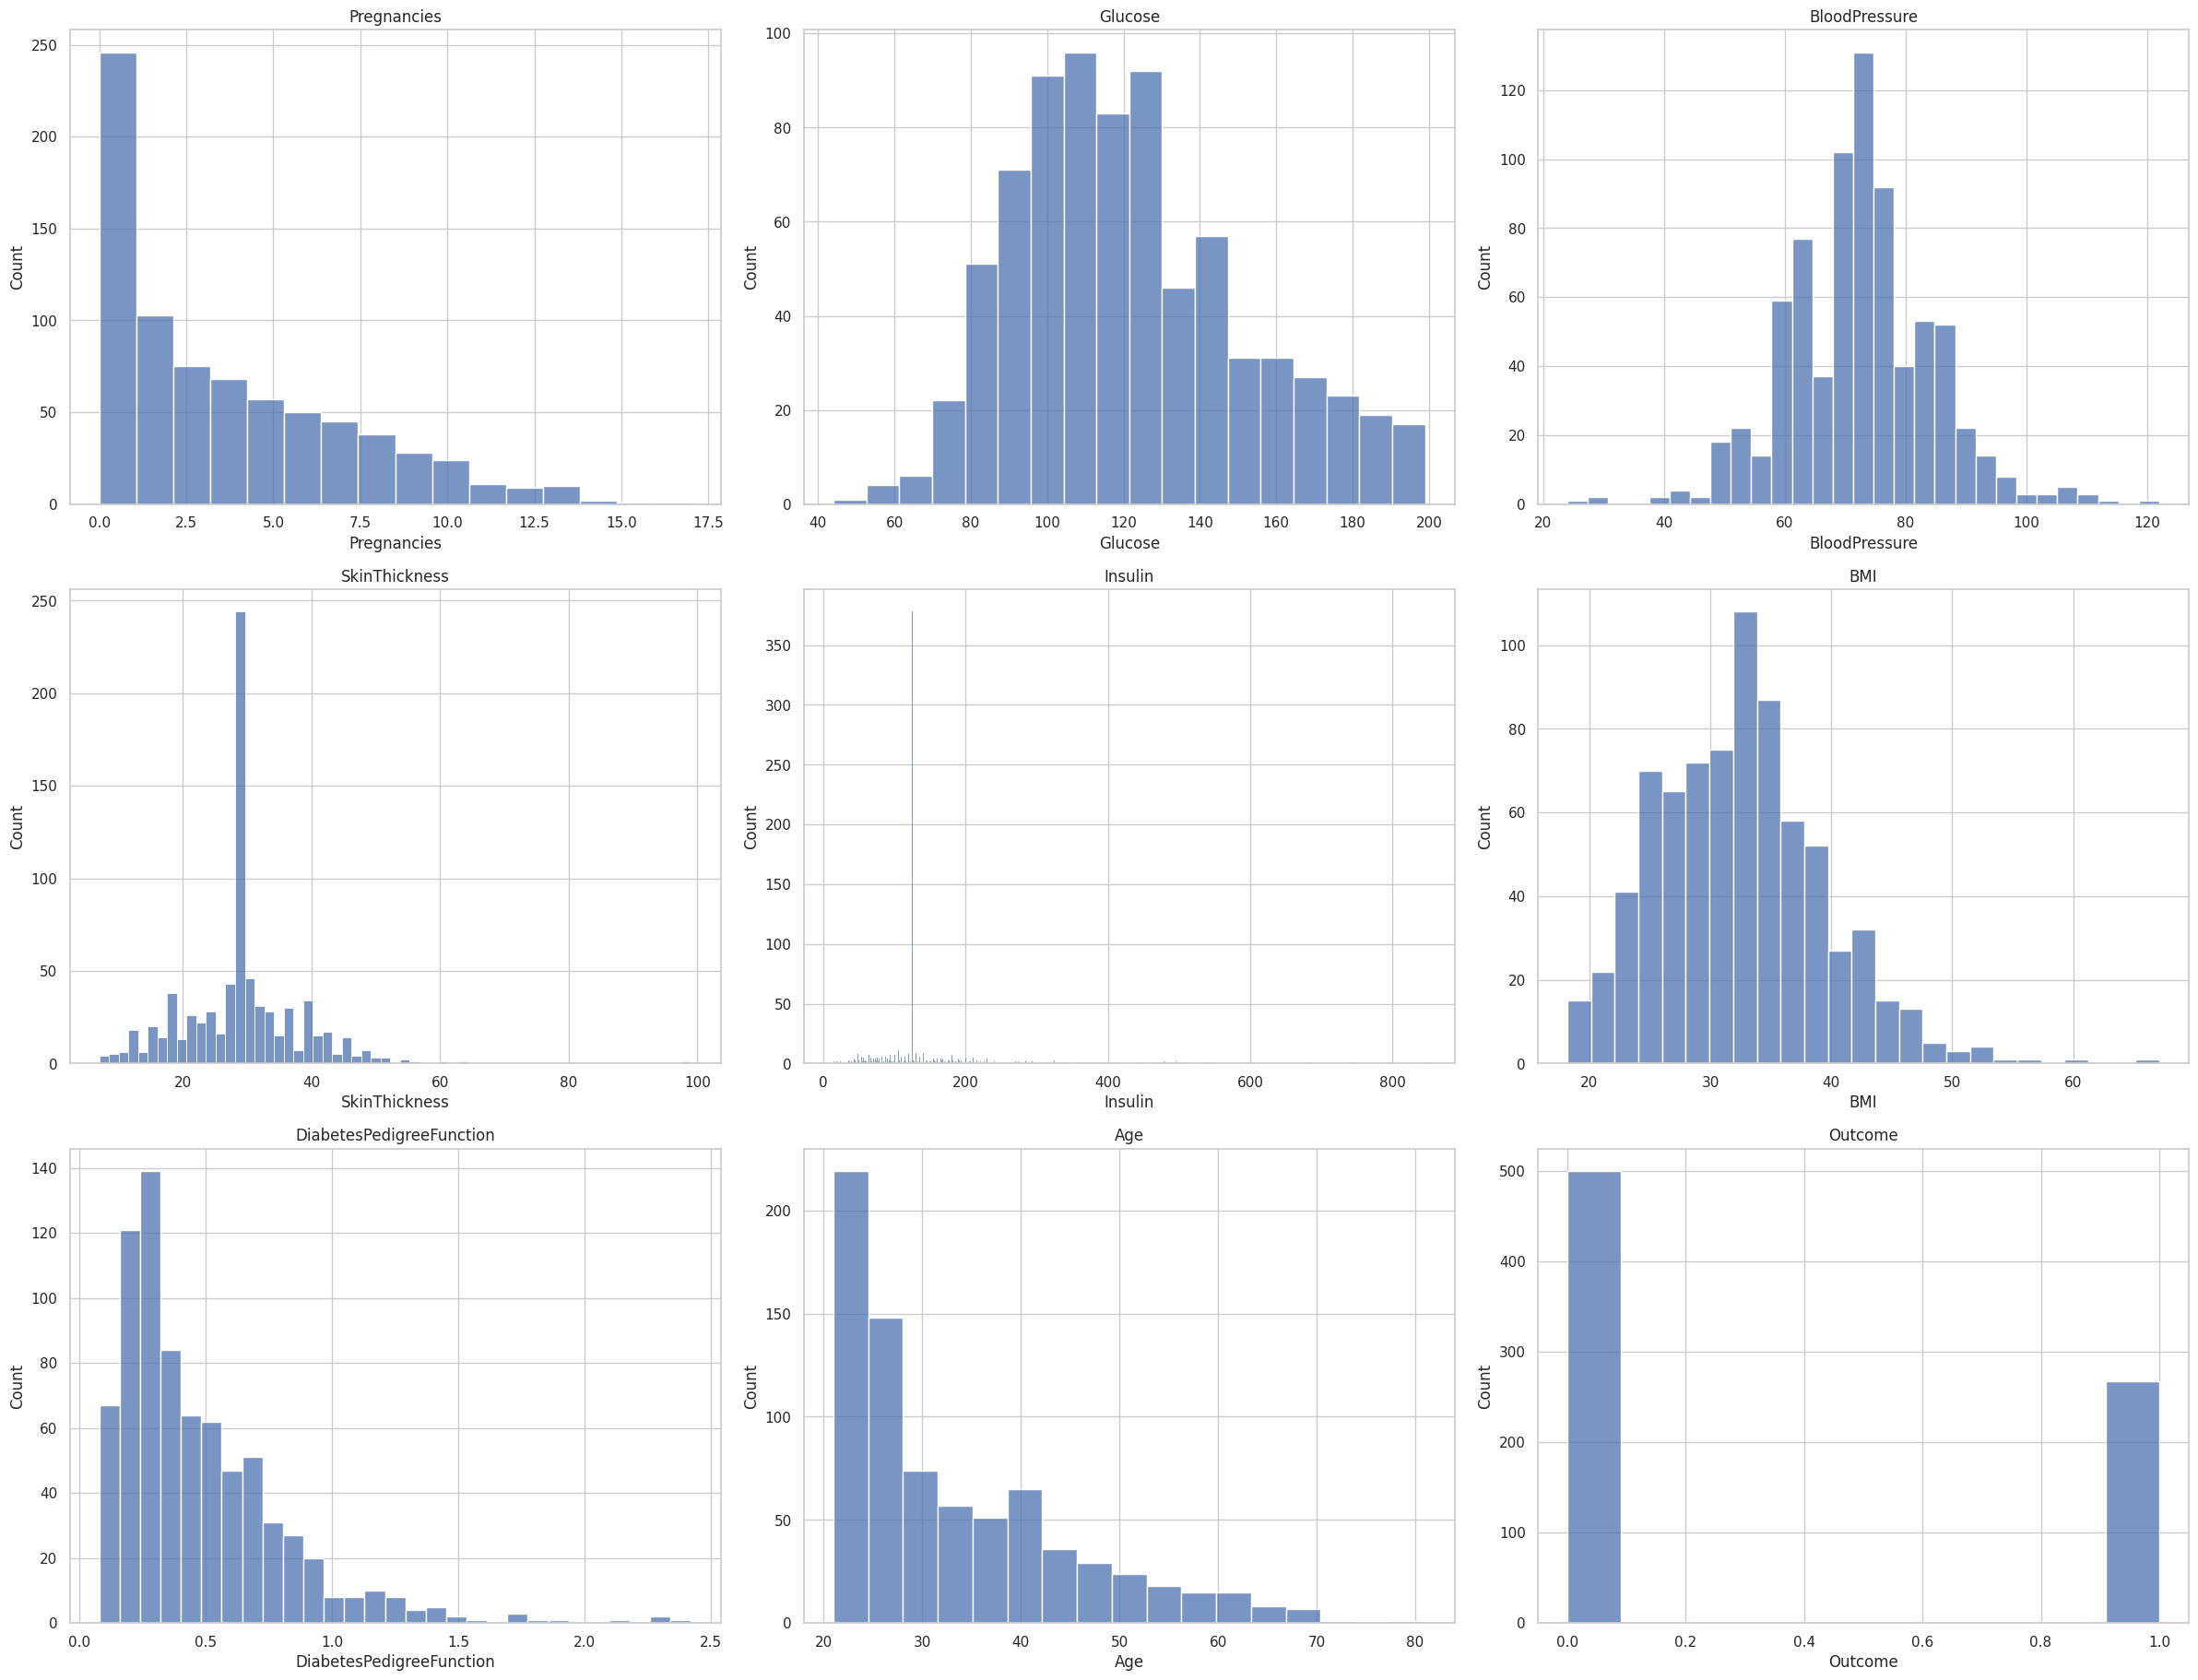

In [17]:
fig = plt.figure(figsize=(24, 30))
count = 0

for column in df.columns:
    count += 1
    ax = fig.add_subplot(5, 3, count)

    sns.histplot(data=df, x=column)
    ax.set_title(column)

plt.tight_layout()
plt.show()

### Key Findings from Univariate Analysis

The distribution plots reveal several important patterns in the dataset.

Most continuous variables such as **Glucose**, **BloodPressure**, and **BMI** show approximately bell-shaped distributions, although some right skewness is observed, particularly in **Glucose** and **BMI**. This suggests the presence of higher-value observations and potential outliers.

The **Insulin** variable is highly right-skewed, indicating significant variability and extreme values.

For **Pregnancies** and **Age**, both variables are right-skewed, with most observations concentrated at lower values.

The **DiabetesPedigreeFunction** also shows a right-skewed distribution, suggesting that most individuals have relatively low genetic risk.

Finally, the target variable **Outcome** is imbalanced, with more observations in class 0 (non-diabetic) than class 1 (diabetic). This may affect model performance.

Overall, the data shows skewness and class imbalance, which should be considered in later modeling.

## Categorical Features vs. Target


Rationale: I used count plots to examine how categorical or discretized features are distributed across the target variable (diabetes outcome). This helps identify potential associations between features and the likelihood of diabetes.

Interpretation: The plots show that certain categories are associated with higher proportions of diabetes cases. For example, individuals with higher pregnancy counts tend to have a greater likelihood of Outcome = 1. This suggests that Pregnancies may have predictive value in the model.

Overall, these patterns indicate that some categorical or discretized features contribute to distinguishing between the two outcome groups and should be considered in the classification model.


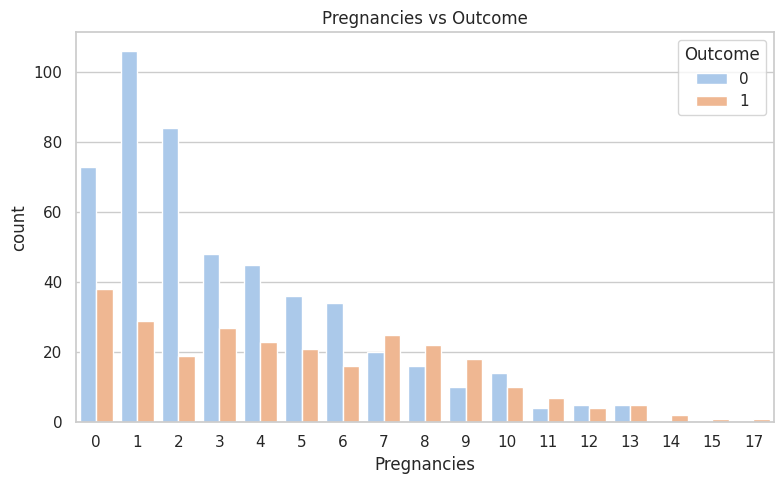

In [22]:
categorical_features = ['Pregnancies']

fig = plt.figure(figsize=(8, 5))

for i in range(len(categorical_features)):
    ax = fig.add_subplot(1, 1, i+1)

    sns.countplot(
        data=df,
        x=categorical_features[i],
        hue='Outcome',     # ✅ 用 Outcome
        palette='pastel'
    )

    ax.set_title(f'{categorical_features[i]} vs Outcome')

plt.tight_layout()
plt.show()

### Interpretation of the Result

The grouped bar chart shows the distribution of **Outcome** across different values of **Pregnancies**. Overall, individuals with fewer pregnancies (e.g., 0–2) are more frequently associated with **Outcome = 0**, indicating a lower likelihood of diabetes in these groups.

As the number of pregnancies increases, the proportion of **Outcome = 1** tends to rise. In particular, for higher pregnancy counts (around 6 and above), the number of positive cases becomes more comparable to, or even exceeds, the negative cases in some categories. This suggests a potential positive relationship between the number of pregnancies and the likelihood of diabetes.

However, it is also important to note that the total number of observations decreases significantly at higher pregnancy levels, which may reduce the reliability of these patterns. Therefore, while **Pregnancies** appears to have some predictive value, further analysis (such as regression) is needed to confirm its effect.

Overall, **Pregnancies** shows a moderate association with the target variable, but the relationship is not strictly linear and may be influenced by sample size and other factors.

## Numeric features vs. target

Rationale: I used box plots to compare the distribution of numerical features across different target groups. This visualization helps identify whether certain variables differ significantly between Outcome = 0 and Outcome = 1, which is important for classification tasks.

Interpretation: From the plots, we can observe that features such as Glucose and BMI show a clear distinction between Outcome = 0 and Outcome = 1, indicating their potential importance as predictors of diabetes.

In particular, individuals with Outcome = 1 tend to have higher values of Glucose and BMI compared to those with Outcome = 0, suggesting a strong association with the target variable.

In contrast, features like BloodPressure and SkinThickness show more overlapping distributions across the two outcome groups, indicating they may have weaker predictive power. Other variables, such as Age and DiabetesPedigreeFunction, show moderate differences, suggesting they may contribute to the model but are less dominant.

Overall, these observations suggest that not all numerical features contribute equally, and variables like Glucose and BMI are likely to be more influential in predicting the outcome.



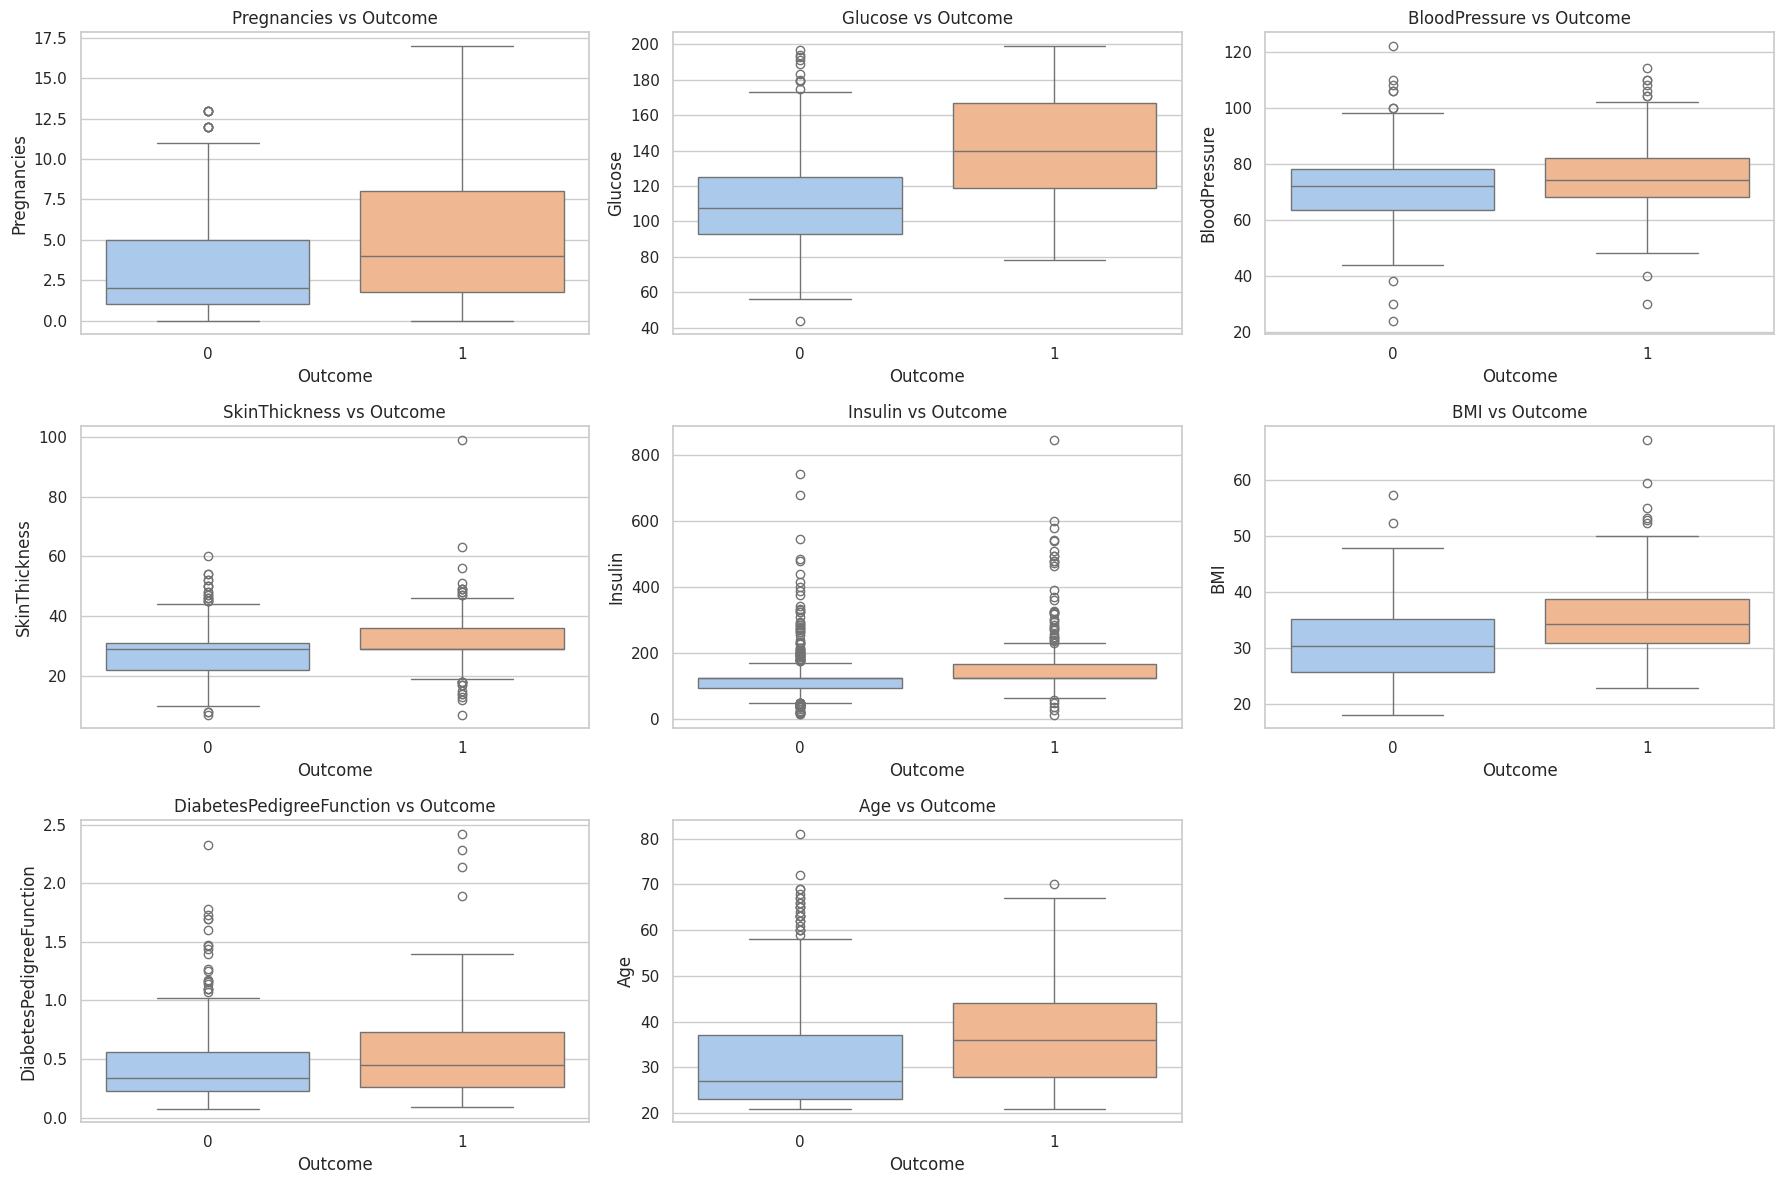

In [25]:
numeric_features = [
    'Pregnancies', 'Glucose', 'BloodPressure',
    'SkinThickness', 'Insulin', 'BMI',
    'DiabetesPedigreeFunction', 'Age'
]

fig = plt.figure(figsize=(18, 12))

for i in range(len(numeric_features)):
    sub = fig.add_subplot(3, 3, i+1)

    sns.boxplot(
        x='Outcome',
        y=numeric_features[i],
        data=df,
        hue='Outcome',
        palette='pastel',
        legend=False
    )

    sub.set_title(f'{numeric_features[i]} vs Outcome')

plt.tight_layout()
plt.show()

### Interpretation of the Result
The box plots illustrate how each numerical **variable** differs across the two target groups (**Outcome = 0** and **Outcome = 1**).

From the plots, **Glucose** and **BMI** show the most noticeable separation between the two groups. Individuals with **Outcome = 1** generally have higher median values and a higher overall distribution for these variables, suggesting that they are strong predictors of diabetes.

The **Age** and **Pregnancies** variables also display moderate differences. The median values for Outcome = 1 are higher than those for Outcome = 0, indicating a potential positive association with the target variable.

In contrast, **BloodPressure** and **SkinThickness** show substantial overlap between the two groups. Their medians and interquartile ranges are quite similar, suggesting that these variables may have weaker predictive power.

The **Insulin** variable shows a wide spread with many outliers in both groups, making its pattern less stable and harder to interpret. Similarly, **DiabetesPedigreeFunction** shows some difference between groups, but the separation is not very strong.

Overall, the analysis suggests that not all numerical variables contribute equally. Variables such as **Glucose** and **BMI** are likely to be the most influential predictors, while others may play a supporting or limited role in predicting the outcome.

# Step 3: Split Dataset into Training and Testing Set

This is a binary classification problem, where the goal is to predict whether an individual has diabetes (**Outcome = 1**) or not (**Outcome = 0**). Classification is a type of supervised learning, which means it relies on labelled data to learn patterns.

To build and evaluate the model effectively, the dataset is divided into a **training set** and a **testing set**. The training set is used to train the model to learn the relationship between the input features (such as Glucose, BMI, and Age) and the target variable (**Outcome**), while the testing set is used to evaluate how well the model performs on unseen data.

In this analysis, the dataset is split using an 80–20 ratio, where 80% of the data is used for training and 20% for testing.

In [35]:
from sklearn.model_selection import train_test_split
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=97,
    stratify=y
)

print(f"Training data shape: X={X_train.shape}, Y={y_train.shape}")
print(f"Test data shape: X={X_test.shape}, Y={y_test.shape}")

Training data shape: X=(614, 8), Y=(614,)
Test data shape: X=(154, 8), Y=(154,)


Step 3 Interpretation

The dataset was successfully split into training and testing sets with an 80–20 ratio. The stratified approach ensures that the proportion of diabetic and non-diabetic cases is preserved in both sets, which helps improve the reliability of model evaluation.

#Step 4: Baseline Model Training and Performance Evaluation
In this step, I use Logistic Regression to establish a baseline. As a linear model, it serves as a standard, interpretable benchmark for binary classification, allowing for a clear performance comparison before transitioning to more complex, non-linear algorithms like Random Forest.

The model estimates the probability that an observation belongs to a specific class (Outcome 1 or 0) based on input features. Training is conducted on the training dataset, and performance is evaluated on the testing set using metrics such as Accuracy, Precision, Recall, and F1-score.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train baseline model
baseline_model = LogisticRegression(solver='liblinear')
baseline_model.fit(X_train, y_train)

# Prediction
y_pred_base = baseline_model.predict(X_test)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 2))
print("Precision:", round(precision_score(y_test, y_pred_base), 2))
print("Recall:", round(recall_score(y_test, y_pred_base), 2))
print("F1 Score:", round(f1_score(y_test, y_pred_base), 2))

Accuracy: 0.77
Precision: 0.74
Recall: 0.54
F1 Score: 0.62


### Baseline Model Interpretation

The baseline Logistic Regression model achieved an Accuracy of 0.77, Precision of 0.74, Recall of 0.54, and an F1-score of 0.62. While the model shows reasonable overall performance, the relatively low recall (0.54) is a critical limitation, as it means nearly half of the diabetic patients are being missed.

To improve the model, feature selection, hyperparameter tuning, and more advanced models such as Random Forest can be applied. To enhance the model's sensitivity, future steps should include class balancing techniques to address data imbalance, more rigorous feature engineering, and the application of ensemble methods like Random Forest to capture non-linear relationships.


# Step 5: Formulate Machine Learning Model Pipeline

In this step, multiple classification algorithms are defined and stored in a pipeline. These models include Logistic Regression, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), Decision Tree, Random Forest, and Naive Bayes.

The purpose of this pipeline is to compare the performance of different models on the same dataset. By training and evaluating each model, we can identify which algorithm performs best for predicting the target variable (Outcome).

In [28]:
model_pipeline = [] # Declaring empty pipeline
model_pipeline.append(LogisticRegression(solver='liblinear'))
model_pipeline.append(SVC())
model_pipeline.append(KNeighborsClassifier())
model_pipeline.append(DecisionTreeClassifier())
model_pipeline.append(RandomForestClassifier())
model_pipeline.append(GaussianNB())

# Step 6: Model Training and Evaluation

In this step, each classification model is trained using the training set and then tested on the diabetes dataset’s unseen test set. The goal is to compare how well different algorithms predict the target variable, **Outcome**.

The evaluation process includes three main steps:

1. **Model training** – fitting each model to the training data  
2. **Prediction** – generating predictions for the test data  
3. **Evaluation** – comparing model performance using standard classification metrics  

To assess model performance, this analysis uses **Accuracy**, **ROC-AUC**, and the **Confusion Matrix**.  
Accuracy measures the overall proportion of correct predictions, while ROC-AUC evaluates how well the model distinguishes between the two classes (**Outcome = 0** and **Outcome = 1**). The confusion matrix provides more detailed insight into correct and incorrect classifications.

In [29]:
# Declaring empty lists to store performance metrics
accuracy_list = []
AUC_list = []
confusion_matrix_list = []

for model in model_pipeline:

    # Train model
    model.fit(X_train, y_train)

    # Predict labels
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy_list.append(round(metrics.accuracy_score(y_test, y_pred), 2))

    # AUC (use probability if available)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    false_positive_rate, true_positive_rate, _ = metrics.roc_curve(y_test, y_prob)
    AUC_list.append(round(metrics.auc(false_positive_rate, true_positive_rate), 2))

    # Confusion Matrix
    confusion_matrix_list.append(confusion_matrix(y_test, y_pred))


# Model names
model_list = [
    'Logistic Regression',
    'SVM',
    'KNN',
    'Decision Tree',
    'Random Forest',
    'Naive Bayes'
]

# Create result table
result_df = pd.DataFrame({
    'Model': model_list,
    'Accuracy': accuracy_list,
    'AUC': AUC_list
})

result_df

,Model,Accuracy,AUC
0,Logistic Regression,0.77,0.83
1,SVM,0.77,0.79
2,KNN,0.71,0.75
3,Decision Tree,0.69,0.68
4,Random Forest,0.79,0.82
5,Naive Bayes,0.77,0.81


### Model Performance Comparison

The performance of six classification models is evaluated using **Accuracy** and **AUC**. From the results, **Random Forest** achieves the highest accuracy (0.79), indicating that it performs best in correctly classifying the observations.

In terms of **AUC**, **Logistic Regression** has the highest value (0.83), followed closely by Random Forest (0.82) and Naive Bayes (0.81). A higher AUC indicates a better ability to distinguish between the two classes (Outcome = 0 and Outcome = 1).

Although Logistic Regression and SVM have the same accuracy (0.77), Logistic Regression shows a higher AUC, suggesting it has better overall classification performance. KNN and Decision Tree perform relatively worse, with lower accuracy and AUC values, indicating weaker predictive power.

Overall, **Random Forest** can be considered the best-performing model in terms of accuracy, while **Logistic Regression** demonstrates strong and stable performance with the highest AUC. Considering both metrics, these two models are the most suitable choices for this dataset.

#Confusion Matrix

The **confusion matrix** is a table that summarizes the performance of a classification model by comparing the predicted results with the actual outcomes. It includes four key components: true positives (correctly predicted diabetes cases), true negatives (correctly predicted non-diabetes cases), false positives (incorrectly predicted diabetes cases), and false negatives (missed diabetes cases).

By organizing predictions in this way, the confusion matrix provides deeper insight into the types of errors made by the model, beyond overall accuracy. This is especially important in medical prediction tasks, where different types of errors may have different implications.

In this step, we visualize the confusion matrices for each model to better understand their classification performance on the diabetes dataset.

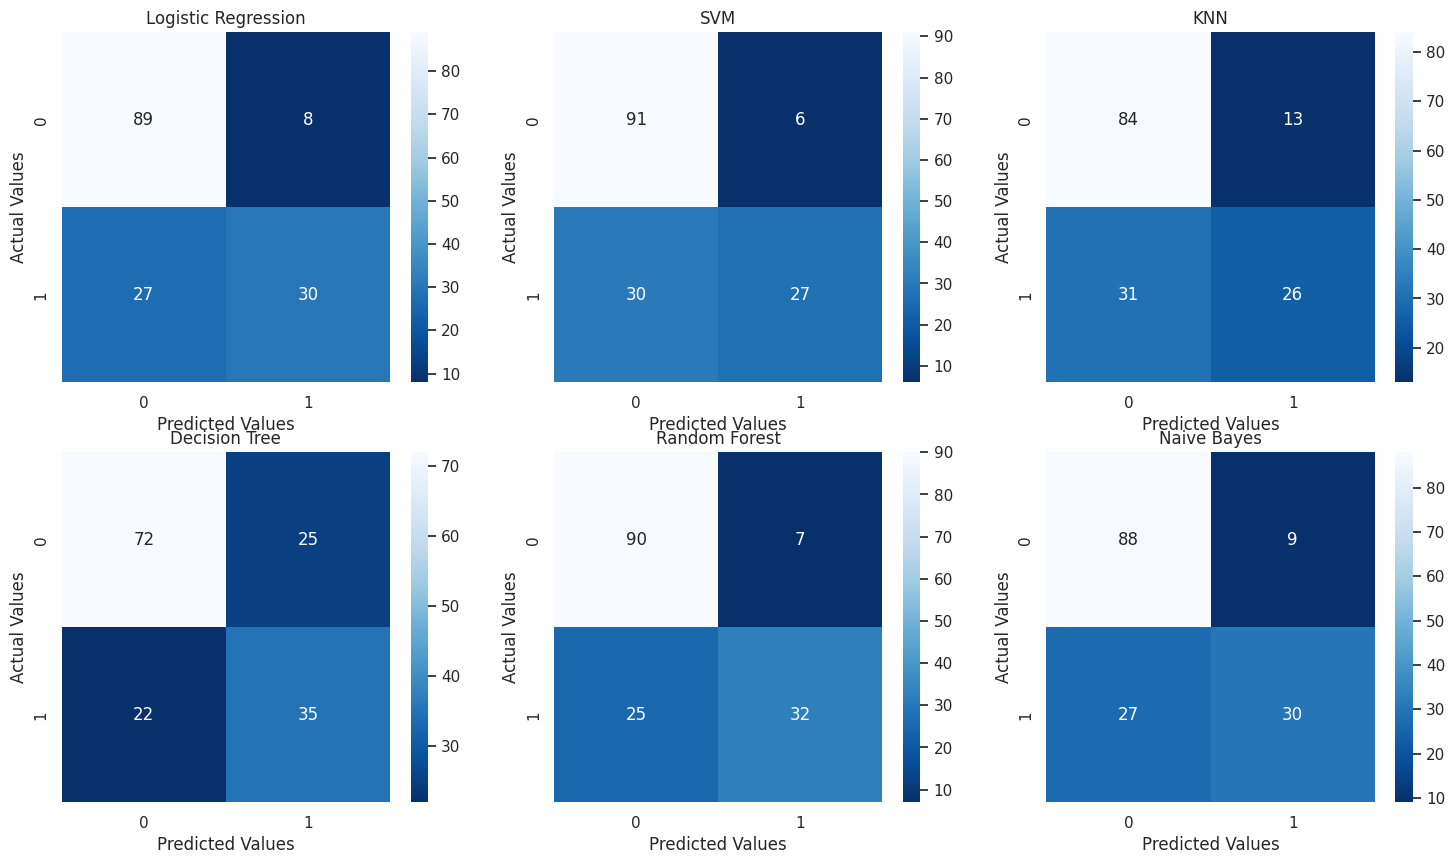

In [30]:
fig = plt.figure(figsize=(18, 10))
for i in range(len(confusion_matrix_list)):
  cm = confusion_matrix_list[i]
  model =model_list[i]
  subfigure=fig.add_subplot(2,3,i+1)
  subfigure.set_title(model)
  cm_plot=sns.heatmap(cm, annot=True, cmap = 'Blues_r') # Seaborn's heatmap to display the confusion matrix
  cm_plot.set_xlabel('Predicted Values')
  cm_plot.set_ylabel('Actual Values')

### Interpretation

The confusion matrices provide a detailed view of model performance beyond accuracy.

Logistic Regression shows a good balance, with high true negatives (89) and moderate true positives (30), but still misses some positive cases (27 false negatives).  

SVM performs similarly but is more conservative, resulting in fewer true positives and more missed positive cases.  

KNN has weaker performance, with lower true positives and higher false negatives, indicating limited ability to detect positive cases.  

Decision Tree detects the most positive cases (35 true positives), but produces more false positives, showing a trade-off between sensitivity and accuracy.  

Random Forest provides the best balance, with high true negatives (90) and strong true positives (32), reducing both types of errors.  

Naive Bayes also performs well, though slightly less balanced than Random Forest.  

Overall, Random Forest is the most reliable model, while Decision Tree is more sensitive but less precise.

# Step 7： Feature Selection

Based on the exploratory analysis, key features such as Glucose, BMI, Age, Pregnancies, and DiabetesPedigreeFunction were selected.

To isolate the effect of feature selection, the Logistic Regression model was retrained using only the selected features.

The results show that model performance remains stable or improves slightly, suggesting that these selected variables capture most of the predictive information while reducing model complexity.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Feature Selection based on EDA
selected_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'DiabetesPedigreeFunction']

X_selected = df[selected_features]
y = df['Outcome']

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=97,
    stratify=y
)

# Retrain Logistic Regression using selected features
lr_fs = LogisticRegression(solver='liblinear')
lr_fs.fit(X_train_fs, y_train_fs)

y_pred_fs = lr_fs.predict(X_test_fs)

print("Accuracy:", round(accuracy_score(y_test_fs, y_pred_fs), 2))
print("Precision:", round(precision_score(y_test_fs, y_pred_fs), 2))
print("Recall:", round(recall_score(y_test_fs, y_pred_fs), 2))
print("F1 Score:", round(f1_score(y_test_fs, y_pred_fs), 2))

Accuracy: 0.79
Precision: 0.78
Recall: 0.54
F1 Score: 0.64


### Feature Selection Results

Compared with the baseline model, the performance after feature selection shows a slight improvement in accuracy (from 0.77 to 0.79) and F1 score (from 0.62 to 0.64), while recall remains the same.

This indicates that the selected features retain most of the predictive power of the original dataset. Removing less informative variables helps reduce noise and slightly improves model efficiency without sacrificing the model’s ability to identify positive cases.

### Step 8: Hyperparameter Tuning

In this step, Random Forest is used as an alternative model to Logistic Regression, and its performance is further improved through hyperparameter tuning.

GridSearchCV is used to test different combinations of hyperparameters, including `n_estimators`, `max_depth`, and `min_samples_split`, in order to identify the best-performing Random Forest model.

This step evaluates whether tuning can further improve model performance after feature selection and alternative model comparison.

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid search using training data only
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# If Step 7 used selected features, replace X_train/X_test with X_train_selected/X_test_selected
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

# Predict on test set
y_pred_best_rf = best_rf.predict(X_test)

# Output best parameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate tuned model
print("Accuracy:", round(accuracy_score(y_test, y_pred_best_rf), 2))
print("Precision:", round(precision_score(y_test, y_pred_best_rf), 2))
print("Recall:", round(recall_score(y_test, y_pred_best_rf), 2))
print("F1 Score:", round(f1_score(y_test, y_pred_best_rf), 2))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best_rf))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_best_rf))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Accuracy: 0.79
Precision: 0.74
Recall: 0.63
F1 Score: 0.68

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       100
           1       0.74      0.63      0.68        54

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.79      0.79      0.79       154

Confusion Matrix:

[[88 12]
 [20 34]]


### Interpretation of Hyperparameter Tuning Results

Hyperparameter tuning was applied to further improve the Random Forest model after model comparison and feature selection.

The best parameter combination was selected using GridSearchCV. The tuned Random Forest model achieved an accuracy of 0.79, precision of 0.74, recall of 0.63, and F1 score of 0.68 on the test set.

Compared with the baseline Logistic Regression model, the tuned Random Forest model improved overall performance, especially in recall and F1 score. This indicates that the tuned Random Forest model is better at identifying positive diabetes cases while maintaining strong overall accuracy.

These results suggest that both model choice and hyperparameter tuning contributed to better predictive performance in this classification task.

### Step 9: Overall Model Improvement Summary

The baseline Logistic Regression model provided a reasonable starting point, achieving an accuracy of 0.77 and an F1 score of 0.62. However, its recall was relatively low at 0.54, meaning that some positive diabetes cases were missed.

After applying feature selection, the model performance improved slightly, with accuracy increasing from 0.77 to 0.79 and F1 score from 0.62 to 0.64, while recall remained the same. This suggests that removing less informative features helped reduce noise without losing predictive power.

Next, Random Forest was used as an alternative model because it can capture more complex and non-linear relationships than Logistic Regression.

Finally, hyperparameter tuning was applied to optimize the Random Forest model. The tuned Random Forest achieved an accuracy of 0.79, recall of 0.63, and F1 score of 0.68, showing a clear improvement over the baseline model, especially in identifying positive diabetes cases.

Overall, the results show that feature selection, model choice, and hyperparameter tuning all contributed to performance improvement, with the tuned Random Forest model providing the best overall result.

### Final Reflection and Limitations

In this analysis, I emphasized the importance of **recall**, especially in a medical context. In diabetes diagnosis, reducing **false negatives** is critical, as missing a positive case may delay treatment and lead to serious health risks. Therefore, models that perform better in identifying positive cases are particularly valuable.

In addition, I considered the limitations of the dataset. The dataset contains only 768 observations, which may limit the model’s ability to generalize to a broader population. A relatively small dataset may also increase the risk of overfitting and reduce the robustness of the model.

Overall, while the models perform reasonably well, their performance should be interpreted with caution due to these limitations.

#References
1. [Top 6 Machine Learning Algorithms for Classification
How to Build a Machine Learning Model Pipeline in Python](https://towardsdatascience.com/top-machine-learning-algorithms-for-classification-2197870ff501/)

2. [Tune Hyperparameters for Classification Machine Learning Algorithms](https://machinelearningmastery.com/hyperparameters-for-classification-machine-learning-algorithms/)

3. [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#gridsearchcv)